# **20장. 앙상블 모델**

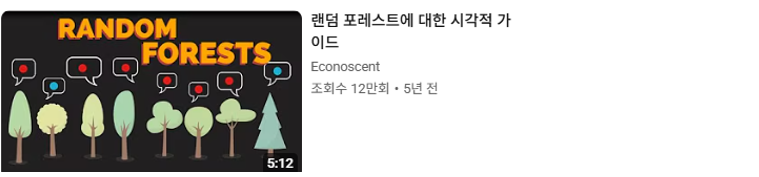

https://www.youtube.com/watch?v=cIbj0WuK41w

이 동영상은 랜덤 포레스트 모델의 작동 원리를 잘 설명하고 있습니다.
* 트리들의 다양성을 확보하는 것이 핵심이 됩니다.


---



In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt; import seaborn as sns
from sklearn.ensemble import RandomForestRegressor as RFR  # 랜덤포레스트 회귀 모델
from lightgbm import LGBMRegressor as LGBMR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 46.8 MB/s eta 0:00:00


## 회귀 문제

[실습 20-01]

In [ ]:
df=pd.read_csv("바이크_임대.csv", encoding="cp949")

y=df["임대_건수"]
X=df.drop(["임대_건수"], axis=1)

X.head(5)

,월,시간대,기온,습도,풍속,자외선,강우량,강설량
0,01월,1시,-3.2,40,0.5,0.0,0.0,0.0
1,01월,2시,-3.3,41,0.7,0.0,0.0,0.0
2,01월,3시,-3.7,42,0.9,0.0,0.0,0.0
3,01월,4시,-4.0,44,1.0,0.0,0.0,0.0
4,01월,5시,-4.2,53,1.1,0.0,0.0,0.0


[실습 20-02]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X1=X.copy()

for idx in X1.select_dtypes(include=["object"]).columns:
    X1[idx] = le.fit_transform(X1[idx])

X1.head(5)

,월,시간대,기온,습도,풍속,자외선,강우량,강설량
0,0,10,-3.2,40,0.5,0.0,0.0,0.0
1,0,16,-3.3,41,0.7,0.0,0.0,0.0
2,0,17,-3.7,42,0.9,0.0,0.0,0.0
3,0,18,-4.0,44,1.0,0.0,0.0,0.0
4,0,19,-4.2,53,1.1,0.0,0.0,0.0


[실습 20-03]

In [ ]:
# 훈련/검증 데이터 분할
x_train, x_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

### 랜덤 포레스트 모델

[실습 20-04]

In [ ]:
# 설정
앙상블1 = RFR(n_estimators=100,random_state=42)
# 학습
앙상블1.fit(x_train, y_train)
# 예측
y_pred = 앙상블1.predict(x_test)
y_pred

array([145.48, 115.98, 132.37, ..., 139.62, 108.38, 135.95])

[실습 20-05]

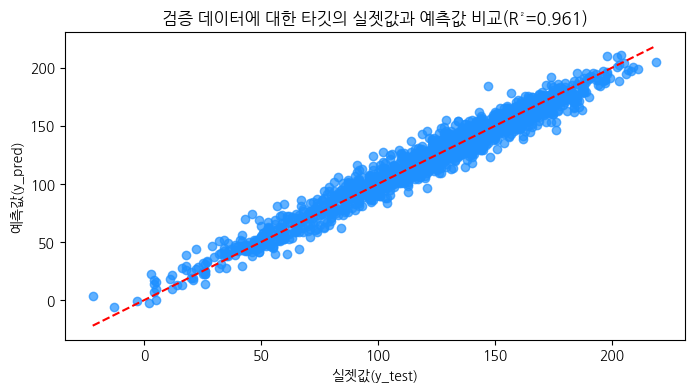

In [ ]:
# 예측 정확도 계산(R-제곱)
r2 = r2_score(y_test, y_pred)

#시각화
plt.figure(figsize=(8, 4))
plt.scatter(y_test, y_pred, color='dodgerblue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='45° Line')
plt.title(f'검증 데이터에 대한 타깃의 실젯값과 예측값 비교(R\u00b2={r2:.3f})')
plt.xlabel('실젯값(y_test)')
plt.ylabel('예측값(y_pred)')
plt.show()

### Light GBM 모델

[실습 20-06]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 756
[LightGBM] [Info] Number of data points in the train set: 7008, number of used features: 8
[LightGBM] [Info] Start training from score 124.696632


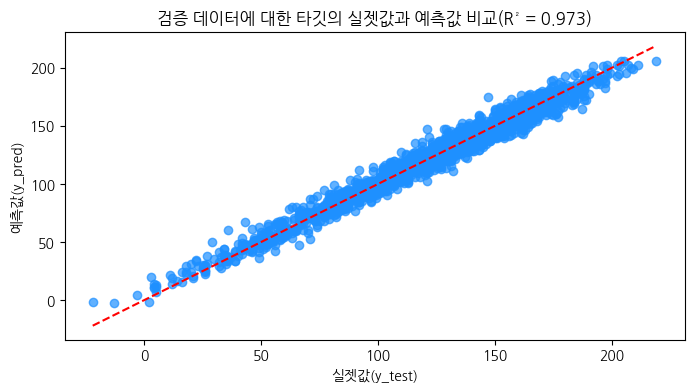

In [ ]:
# 설정
앙상블2 = LGBMR(n_estimators=100,random_state=42)
# 학습
앙상블2.fit(x_train, y_train)
# 예측
y_pred=앙상블2.predict(x_test)

r2=r2_score(y_test, y_pred)   # 예측 정확도 계산

plt.figure(figsize=(8, 4))
plt.scatter(y_test, y_pred, color='dodgerblue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='45° Line')
plt.title(f'검증 데이터에 대한 타깃의 실젯값과 예측값 비교(R² = {r2:.3f})')
plt.xlabel('실젯값(y_test)'); plt.ylabel('예측값(y_pred)')
plt.show()

[실습 20-07]

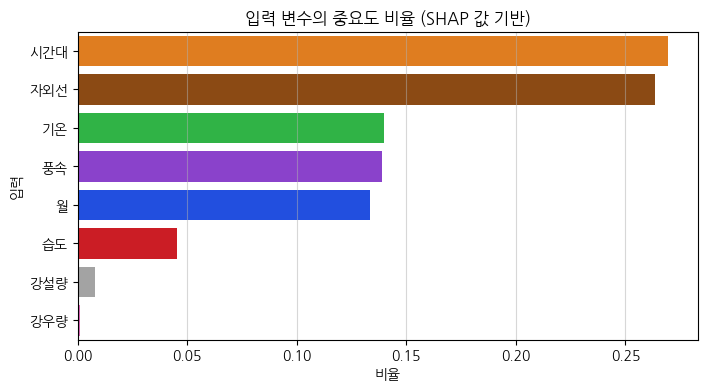

In [ ]:
import shap  # 라이브러리 추가

# 1) SHAP 값 계산
model=shap.TreeExplainer(앙상블2)
shap_values=model.shap_values(x_test)
shap_importance = np.abs(shap_values).mean(axis=0)

# 2) 비율로 변환
shap_ratio = shap_importance / shap_importance.sum()

# 3) 비율이 큰 순서(내림차순)로 컬럼 이름 정렬
sorted_columns = x_test.columns[np.argsort(shap_ratio)[::-1]]

# 4) 시각화
plt.figure(figsize=(8,4))
sns.barplot(y=x_test.columns, x=shap_ratio, hue=x_test.columns, palette='bright', order=sorted_columns)
plt.xlabel("비율"); plt.ylabel("입력")
plt.title("입력 변수의 중요도 비율 (SHAP 값 기반)")
plt.grid(axis='x',alpha=0.5)
plt.show()

[실습 20-08]

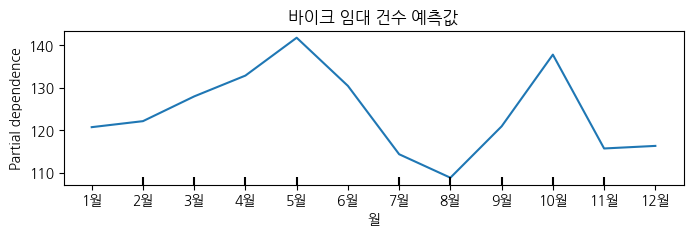

In [ ]:
from sklearn.inspection import PartialDependenceDisplay as PDP

# PDP 시각화
fig, ax= plt.subplots(figsize=(8, 2))
관심_특성="월"
PDP.from_estimator(앙상블2, x_test,
                   features=[관심_특성],
                   kind='average',
                   ax=ax)

plt.title(f"바이크 임대 건수 예측값")
월_라벨 = ['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월']
plt.xticks(ticks=range(0, 12), labels=월_라벨)
plt.show()

[실습 20-09]

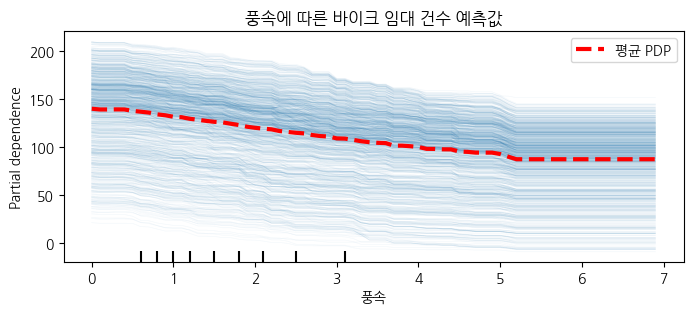

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
관심_특성="풍속"
PDP.from_estimator(앙상블2, x_test,
                   features=[관심_특성],
                   kind='both',
                   ax=ax,
                   ice_lines_kw={"alpha": 0.05},
                   pd_line_kw={"color": "red", "linewidth": 3, "label": "평균 PDP"}
                                      )
plt.title(f"{관심_특성}에 따른 바이크 임대 건수 예측값")
plt.show()

## 분류 문제  

In [ ]:
from sklearn.ensemble import RandomForestClassifier as RFC  # 랜덤포레스트 회귀 모델
from lightgbm import LGBMClassifier as LGBMC # LGBM 분류 모델
from sklearn.metrics import confusion_matrix, accuracy_score

[실습 20-10]

In [ ]:
df = pd.read_csv("와인품질.csv", encoding='cp949')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.6,0.645,0.03,1.90,0.086,14.0,57.0,0.99690,3.37,0.46,10.3,Bad
1,8.0,0.250,0.43,1.70,0.067,22.0,50.0,0.99460,3.38,0.60,11.9,Good
2,7.7,0.835,0.00,2.60,0.081,6.0,14.0,0.99750,3.30,0.52,9.3,Bad
3,8.3,0.850,0.14,2.50,0.093,13.0,54.0,0.99724,3.36,0.54,10.1,Bad
4,7.8,0.390,0.42,2.00,0.086,9.0,21.0,0.99526,3.39,0.66,11.6,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
795,11.2,0.670,0.55,2.30,0.084,6.0,13.0,1.00000,3.17,0.71,9.5,Bad
796,9.1,0.660,0.15,3.20,0.097,9.0,59.0,0.99976,3.28,0.54,9.6,Bad
797,8.9,0.480,0.24,2.85,0.094,35.0,106.0,0.99820,3.10,0.53,9.2,Bad
798,9.4,0.340,0.37,2.20,0.075,5.0,13.0,0.99800,3.22,0.62,9.2,Bad


[실습 20-11]

In [ ]:
# 타깃을  라벨 인코딩
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['quality']) # 0=Bad, 1=Good
print(y[:5]); print()

X=df.drop(["quality"], axis=1)  # 타깃 제외한 11개 성분을 입력으로 지정
print(X[:5])

[0 1 0 0 1]

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.6             0.645         0.03             1.9      0.086   
1            8.0             0.250         0.43             1.7      0.067   
2            7.7             0.835         0.00             2.6      0.081   
3            8.3             0.850         0.14             2.5      0.093   
4            7.8             0.390         0.42             2.0      0.086   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 14.0                  57.0  0.99690  3.37       0.46   
1                 22.0                  50.0  0.99460  3.38       0.60   
2                  6.0                  14.0  0.99750  3.30       0.52   
3                 13.0                  54.0  0.99724  3.36       0.54   
4                  9.0                  21.0  0.99526  3.39       0.66   

   alcohol  
0     10.3  
1     11.9  
2      9.3  
3     10.1  
4     11

[실습 20-12]

In [ ]:
# 훈련/검증 데이터 분할
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

[실습 20-13]

In [ ]:
# 설정
앙상블3=LGBMC(n_estimators=500, random_state=42, verbosity=-1)  # 튜닝 필요

# 학습
앙상블3.fit(x_train, y_train)

# 예측
y_pred = 앙상블3.predict(x_test)
print(y_pred)

[0 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 0 1 0 0 0 1 0 1 0 1 0 0 1 0 0 0 1 0 0 0 1
 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1 1 0 1 0 1 0 0 0 1 0 1 0 1 0 1 0 0 1
 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 1 1 0 0 1 0 0 0 0 1
 0 0 0 1 0 0 0 1 0 1 1 0 1 1 0 0 1 1 1 1 0 1 1 1 1 0 0 0 0 0 1 0 0 0 1 1 0
 0 1 0 0 0 0 0 0 0 0 0 1]


[실습 20-14]

In [ ]:
y_pred_prob = 앙상블3.predict_proba(x_test)  # 각 클래스의 예측 확률 계산

y_prob=pd.DataFrame(np.round(y_pred_prob,3), columns=['Bad', 'Good']) # 데이터프레임 변환

y_prob

,Bad,Good
0,1.000,0.000
1,0.000,1.000
2,0.001,0.999
3,0.473,0.527
4,1.000,0.000
...,...,...
155,1.000,0.000
156,0.982,0.018
157,1.000,0.000
158,1.000,0.000


📌예측 정확도 시각화하기

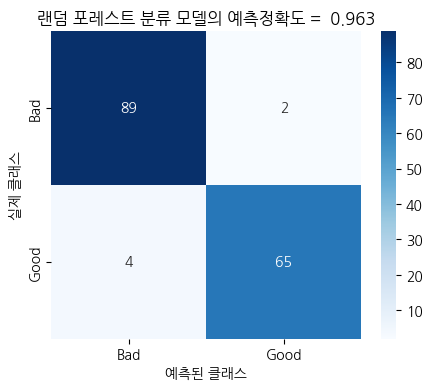

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
class_names=["Bad", "Good"]
cm = pd.crosstab(y_test, y_pred)      # 혼동행렬
acc = accuracy_score(y_test, y_pred)  # 검증용 데이터 분류정확도
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.ylabel("실제 클래스"); plt.xlabel("예측된 클래스")
plt.title(f"랜덤 포레스트 분류 모델의 예측정확도 = {acc: .3f}"); plt.show()


📌특성 중요도

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


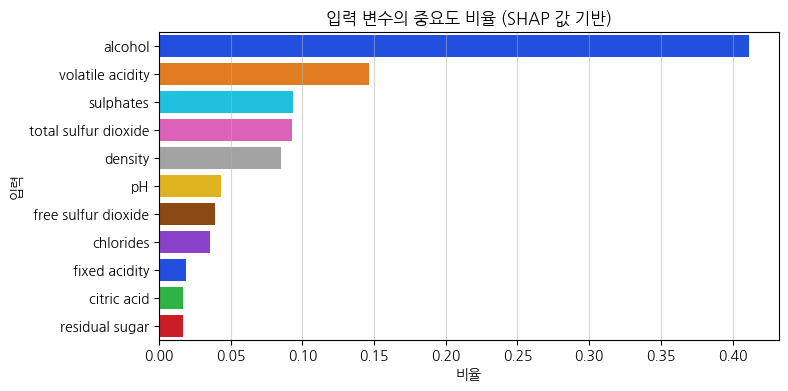

In [ ]:
import shap  # 라이브러리 추가

# 1) SHAP 값 계산
model=shap.TreeExplainer(앙상블3)
shap_values = model.shap_values(x_test)
shap_importance = np.abs(shap_values).mean(axis=0)

# 2) 비율로 변환
shap_ratio = shap_importance / shap_importance.sum()

# 3) 비율이 큰 순서(내림차순)로 컬럼 이름 정렬
sorted_columns = x_test.columns[np.argsort(shap_ratio)[::-1]]

# 4) 시각화
plt.figure(figsize=(8,4))
sns.barplot(y=x_test.columns, x=shap_ratio, hue=x_test.columns, palette='bright', order=sorted_columns,)
plt.xlabel("비율"); plt.ylabel("입력")
plt.title("입력 변수의 중요도 비율 (SHAP 값 기반)")
plt.grid(axis='x',alpha=0.5)
plt.show()

[실습 20-15]

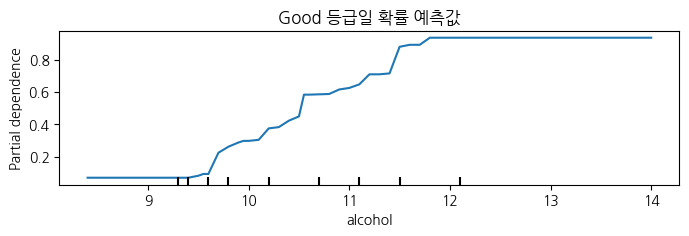

In [ ]:
fig, ax = plt.subplots(figsize=(8, 2))

관심_특성="alcohol"

PDP.from_estimator(앙상블3, X,
              features=[관심_특성],
              kind='average',    # 나머지 특성 변수는 평균으로 고정
              target=1,          # 확률을 구하고자 하는 클래스의 위치 번호 지정
              ax=ax)

plt.title("Good 등급일 확률 예측값")
plt.show()

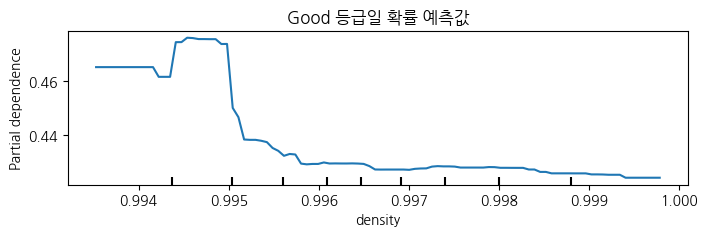

In [ ]:
fig, ax = plt.subplots(figsize=(8, 2))

관심_특성="density"
PDP.from_estimator(앙상블3, X,
                   features=[관심_특성],
                   kind='average',
                   target=1,
                   ax=ax)
plt.title("Good 등급일 확률 예측값")
plt.show()